<a href="https://colab.research.google.com/github/logavanancsele2528-afk/BULK-CERTIFICATION/blob/main/loga.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

n_users = 200

# 1. User ID
user_ids = [f"USR_{i:03d}" for i in range(1, n_users + 1)]

# 2. Age
ages = np.random.randint(21, 65, size=n_users)

# 3. Employment Status
employment_options = ["Employed", "Self-Employed", "Unemployed"]
employment_status = np.random.choice(employment_options, size=n_users, p=[0.75, 0.18, 0.07])

# 4. Annual Income
incomes = []
for emp in employment_status:
    if emp == "Employed":
        incomes.append(np.random.randint(40000, 140000))
    elif emp == "Self-Employed":
        incomes.append(np.random.randint(30000, 150000))
    else:
        incomes.append(np.random.randint(10000, 30000))
incomes = np.array(incomes)

# 5. Credit Score
credit_scores = np.random.randint(300, 850, size=n_users)

# 6. Loan Amount Requested
loan_amounts = np.random.randint(5000, 95000, size=n_users)

# 7. Debt-to-Income (DTI) Ratio
dti_ratios = np.round(np.random.uniform(0.1, 0.6, size=n_users), 2)

# 8. Loan Status logic based on features
loan_statuses = []
for i in range(n_users):
    score = 0
    # Scoring based on rules
    if credit_scores[i] >= 670: score += 3
    elif credit_scores[i] >= 580: score += 1

    if dti_ratios[i] <= 0.36: score += 2
    elif dti_ratios[i] <= 0.45: score += 1

    if employment_status[i] in ["Employed", "Self-Employed"]: score += 1

    if incomes[i] > loan_amounts[i] * 0.5: score += 1

    # Probability mapping and final assignment
    prob = np.clip(score / 7.0, 0.05, 0.95)
    status = "Approved" if np.random.rand() < prob else "Rejected"
    loan_statuses.append(status)

# Create DataFrame with 8 columns
df = pd.DataFrame({
    "User_ID": user_ids,
    "Age": ages,
    "Employment_Status": employment_status,
    "Annual_Income": incomes,
    "Credit_Score": credit_scores,
    "Loan_Amount": loan_amounts,
    "DTI_Ratio": dti_ratios,
    "Loan_Status": loan_statuses
})

print("Loan Status Distribution:")
print(df["Loan_Status"].value_counts())
print("\nFirst 5 rows of the generated dataset:")
display(df.head())

Loan Status Distribution:
Loan_Status
Approved    110
Rejected     90
Name: count, dtype: int64

First 5 rows of the generated dataset:


,User_ID,Age,Employment_Status,Annual_Income,Credit_Score,Loan_Amount,DTI_Ratio,Loan_Status
0,USR_001,59,Employed,49823,831,65004,0.31,Approved
1,USR_002,49,Employed,100160,740,67981,0.47,Approved
2,USR_003,35,Employed,81975,701,89659,0.57,Approved
3,USR_004,63,Employed,49540,346,59553,0.56,Rejected
4,USR_005,28,Employed,56364,532,53447,0.33,Approved


### Step 1: Preprocess the Data and Split into Train/Test Sets

We need to convert our categorical features into numeric formats and separate the target column (`Loan_Status`) from the features.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define our features (X) and target variable (y)
# We drop 'User_ID' as it's a unique identifier with no predictive value
X = df.drop(columns=['User_ID', 'Loan_Status'])
y = df['Loan_Status'].map({'Approved': 1, 'Rejected': 0}) # Encode target as 1/0

# Identify numerical and categorical columns
num_cols = ['Age', 'Annual_Income', 'Credit_Score', 'Loan_Amount', 'DTI_Ratio']
cat_cols = ['Employment_Status']

# Create preprocessing pipelines for both numeric and categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first'), cat_cols)
    ]
)

# Split data into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (160, 6)
Testing set shape: (40, 6)


### Step 2: Define and Train the Logistic Regression Model

We will build a pipeline that first applies the preprocessing steps and then trains a `LogisticRegression` classifier.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Create the pipeline combining preprocessor and Logistic Regression
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])

# Train the model
model_pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model_pipeline.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Rejected', 'Approved']))

Accuracy: 65.00%

Classification Report:
              precision    recall  f1-score   support

    Rejected       0.60      0.67      0.63        18
    Approved       0.70      0.64      0.67        22

    accuracy                           0.65        40
   macro avg       0.65      0.65      0.65        40
weighted avg       0.65      0.65      0.65        40



### Step 3: Visualize the Confusion Matrix

Let's plot a confusion matrix to visualize how well the model predicts each class.

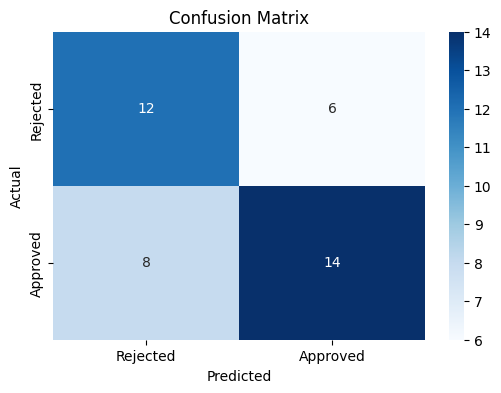

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected', 'Approved'],
            yticklabels=['Rejected', 'Approved'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Step 4: Model Diagnostic Plots (Bias & Variance Check)

To analyze the bias and variance of our model, we will plot:
1. **ROC Curve**: To see our model's performance trade-off at various thresholds (helps assess overall model capability/variance).
2. **Predicted Probabilities Distribution**: Grouped by actual class labels. This helps inspect how confidently (bias) and correctly the model separates the two classes.

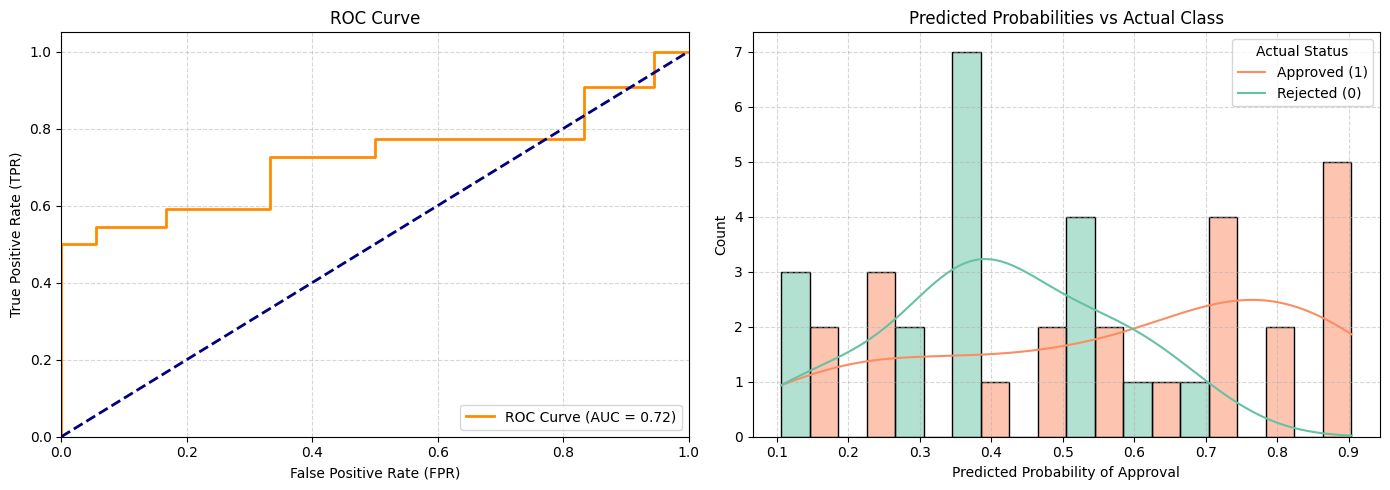

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np

# Get predicted probabilities for the positive class (Approved)
y_prob = model_pipeline.predict_proba(X_test)[:, 1]

# Calculate ROC metrics
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. ROC Curve
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_score:.2f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate (FPR)')
axes[0].set_ylabel('True Positive Rate (TPR)')
axes[0].set_title('ROC Curve')
axes[0].legend(loc="lower right")
axes[0].grid(True, linestyle='--', alpha=0.5)

# 2. Distribution of Predicted Probabilities by Actual Class
prob_df = pd.DataFrame({'Probability': y_prob, 'Actual': y_test.values})

sns.histplot(data=prob_df, x='Probability', hue='Actual', kde=True, bins=10, ax=axes[1], multiple='dodge', palette='Set2')
axes[1].set_title('Predicted Probabilities vs Actual Class')
axes[1].set_xlabel('Predicted Probability of Approval')
axes[1].set_ylabel('Count')
axes[1].legend(title='Actual Status', labels=['Approved (1)', 'Rejected (0)'])
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Step 5: Visualizing Distributions with Pie Charts

Let's visualize the proportion of actual vs. predicted outcomes on our test set.

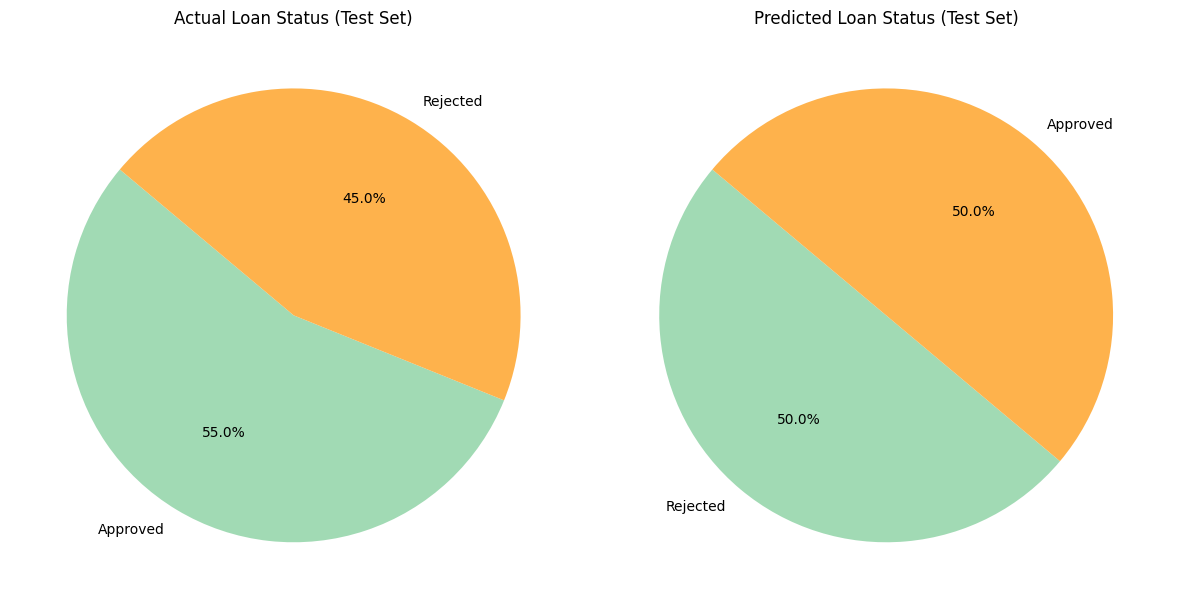

In [ ]:
import matplotlib.pyplot as plt

# Count distributions in our test set
actual_counts = y_test.value_counts().rename(index={1: 'Approved', 0: 'Rejected'})
predicted_counts = pd.Series(y_pred).value_counts().rename(index={1: 'Approved', 0: 'Rejected'})

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# 1. Actual Loan Status Pie Chart
axes[0].pie(actual_counts, labels=actual_counts.index, autopct='%1.1f%%', startangle=140, colors=['#a1dab4', '#feb24c'])
axes[0].set_title('Actual Loan Status (Test Set)')

# 2. Predicted Loan Status Pie Chart
axes[1].pie(predicted_counts, labels=predicted_counts.index, autopct='%1.1f%%', startangle=140, colors=['#a1dab4', '#feb24c'])
axes[1].set_title('Predicted Loan Status (Test Set)')

plt.tight_layout()
plt.show()

### Step 6: Test the Model with Custom Inputs

Use the form below to input custom applicant details and see what our trained Logistic Regression model predicts.

In [11]:
#@title Custom Data Input Form { run: "auto" }

# Input fields using Google Colab's forms
Age = 60 #@param {type:"integer"}
Employment_Status = "Unemployed" #@param ["Employed", "Self-Employed", "Unemployed"]
Annual_Income = 5000 #@param {type:"integer"}
Credit_Score = 510 #@param {type:"slider", min:300, max:850, step:10}
Loan_Amount = 25000 #@param {type:"integer"}
DTI_Ratio = 0.41 #@param {type:"slider", min:0.1, max:0.6, step:0.01}

# Create a DataFrame for the custom input
custom_input_df = pd.DataFrame({
    'Age': [Age],
    'Employment_Status': [Employment_Status],
    'Annual_Income': [Annual_Income],
    'Credit_Score': [Credit_Score],
    'Loan_Amount': [Loan_Amount],
    'DTI_Ratio': [DTI_Ratio]
})

# Predict using the model pipeline
prediction = model_pipeline.predict(custom_input_df)[0]
prediction_prob = model_pipeline.predict_proba(custom_input_df)[0][1]

# Print the results in a clear format
print("== Custom Input Data ==")
display(custom_input_df)
print("\n== Model Prediction ==")
status = "Approved" if prediction == 1 else "Rejected"
print(f"Predicted Status: {status}")
print(f"Probability of Approval: {prediction_prob:.2%}")

== Custom Input Data ==


,Age,Employment_Status,Annual_Income,Credit_Score,Loan_Amount,DTI_Ratio
0,60,Unemployed,5000,510,25000,0.41



== Model Prediction ==
Predicted Status: Rejected
Probability of Approval: 21.26%
